In [2]:
"""
Let's generage some very simple graphs to show the evolution in time. I'll take the circa 33 clusters as 
the reference working csv.
"""

import pandas as pd

cows = pd.read_csv("../Data/dades_clusters.csv")
cols = ["id", "night_date", "lat", "lng", "elevation", "cluster_norm1"]
cows_cluster = cows[cols].copy()

age = pd.read_csv("../Data/dades_calf.csv")
cols = ["id_year", "Edat_real", "Crotal_Joan"]
age = age[cols].copy()
age = age.rename(columns={
    "id_year": "id",
    "Edat_real": "age",
    "Crotal_Joan": "real_id"
})

# Keep only ids in age that appear in cows_cluster
age = age[age["id"].isin(cows_cluster["id"].unique())].copy()

In [3]:
"""
Computes the average amount of other individuals a specific cow spends the night with, giving an estimate
of how social a cow is.
"""

def compute_social_index(cows_cluster):
    
    df = cows_cluster.copy()
    
    # Count cows per night per cluster
    cluster_counts = (
        df.groupby(["night_date", "cluster_norm1"])["id"]
        .count()
        .reset_index(name="cluster_size")
    )
    
    # Merge back
    df = df.merge(cluster_counts, on=["night_date", "cluster_norm1"])
    
    # Number of cows sharing cluster (excluding itself)
    df["shared_cows"] = df["cluster_size"] - 1
    
    # Average per cow
    social_index = (
        df.groupby("id")["shared_cows"]
        .mean()
        .reset_index(name="social_index")
    )
    
    return social_index

social_index_df = compute_social_index(cows_cluster)

In [4]:
"""
Computes the amount of visited clusters with respect to the total amount of data points available and gives
an estimate of the exploration rate of each individual.
"""

def compute_cluster_fraction(cows_cluster):
    
    df = cows_cluster.copy()
    
    # Count visits per cow per cluster
    counts = (df.groupby(["id", "cluster_norm1"]).size().reset_index(name="visits"))
    
    # Total visits per cow
    total_visits = (counts.groupby("id")["visits"].sum().reset_index(name="total_visits"))
    counts = counts.merge(total_visits, on="id")
    
    # Fraction per cluster
    counts["fraction"] = counts["visits"] / counts["total_visits"]
    
    # Get max fraction per cow
    max_fraction = (counts.groupby("id")["fraction"].max().reset_index(name="frac_max"))
    
    return max_fraction

# Calculate the ratio of unique clusters to total observations per ID
visited_clusters = (
    cows_cluster.groupby("id")["cluster_norm1"]
    .agg(unique_clusters="nunique", total_points="count")
    .reset_index()
)

# Create the ratio column
visited_clusters["cluster_ratio"] = (
    visited_clusters["unique_clusters"] / visited_clusters["total_points"]
)

visited_clusters["cluster_saturation"] = (
    visited_clusters["unique_clusters"] / 33
)

fraction_df = compute_cluster_fraction(cows_cluster)

In [5]:
metrics = (
    social_index_df
    .merge(visited_clusters, on="id")
    .merge(fraction_df, on="id")
    .merge(age, on="id")
)
metrics["age_z"] = (
    (metrics["age"] - metrics["age"].mean()) /
    metrics["age"].std()
)

metrics["age_scaled"] = (
    (metrics["age"] - metrics["age"].min()) /
    (metrics["age"].max() - metrics["age"].min())
)

metrics["social_z"] = (
    (metrics["social_index"] - metrics["social_index"].mean()) /
    metrics["social_index"].std()
)

metrics["social_scaled"] = (
    (metrics["social_index"] - metrics["social_index"].min()) /
    (metrics["social_index"].max() - metrics["social_index"].min())
)


In [6]:
"""Builds a panel dataset tracking cumulative unique clusters per night.

    Converts calendar 'night_date' into an integer time_step (1, 2, 3...)
    per cow for mathematical compatibility with log transforms.
    """

def build_temporal_dataframe(cows_cluster, metrics_df):
    df = cows_cluster.copy()

    # If night_date isn't sorted or is a string, let's make sure it's handled chronologically
    df["night_date"] = pd.to_datetime(df["night_date"])

    # Group by id and date to find unique clusters visited on each specific night
    daily_unique = (
        df.groupby(["id", "night_date"])["cluster_norm1"]
        .unique()
        .reset_index()
    )

    # Sort strictly by cow and chronological date
    daily_unique = daily_unique.sort_values(by=["id", "night_date"])

    expanded_rows = []
    for cow_id, group in daily_unique.groupby("id"):
        seen_clusters = set()

        # Enumerate gives us a sequential 0-indexed counter per night for this cow
        for sequence_idx, (_, row) in enumerate(group.iterrows()):
            # Update our running set with clusters from the current night
            seen_clusters.update(row["cluster_norm1"])

            # We add 1 so the sequence starts at t = 1 night (avoiding log(0) issues)
            time_step = sequence_idx + 1

            expanded_rows.append(
                {
                    "id": cow_id,
                    "night_date": row["night_date"],
                    "time_step": time_step,
                    "cumulative_unique": len(seen_clusters),
                }
            )

    temporal_df = pd.DataFrame(expanded_rows)

    # Calculate the environmental saturation fraction (out of 33 spots)
    temporal_df["cluster_saturation"] = (
        temporal_df["cumulative_unique"] / 33.0
    )

    # Merge static predictors (age, social_index) into the longitudinal timeline
    temporal_df = temporal_df.merge(
        metrics_df[["id", "age", "social_index", "real_id"]], on="id", how="inner"
    )

    return temporal_df


# 1. Build the clean, time-indexed longitudinal dataset
df_longitudinal = build_temporal_dataframe(cows_cluster, metrics)

# Preview the panel dataset structure to ensure time_step is tracking correctly
#print("--- Longitudinal Data Preview ---")
#print(df_longitudinal[["id", "night_date", "time_step", "cluster_saturation"]].head(10))

In [7]:
import numpy as np
import statsmodels.formula.api as smf
# Now we can safely compute the natural log using our clean integer intervals
df_longitudinal["log_t"] = np.log(df_longitudinal["time_step"])

# Model formula: Fixed interactions between time, age, and social traits
model_formula = "cluster_saturation ~ log_t * age * social_index"

print("\nFitting Linear Mixed-Effects Model...")
lme_fit = smf.mixedlm(
    formula=model_formula,
    data=df_longitudinal,
    groups=df_longitudinal["real_id"],
).fit()

# Print out the comprehensive statistical summary for your article
print(lme_fit.summary())




Fitting Linear Mixed-Effects Model...
              Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: cluster_saturation
No. Observations:   15235   Method:             REML              
No. Groups:         111     Scale:              0.0028            
Min. group size:    97      Log-Likelihood:     22782.4865        
Max. group size:    322     Converged:          Yes               
Mean group size:    137.3                                         
------------------------------------------------------------------
                       Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept              -0.107    0.028  -3.870 0.000 -0.162 -0.053
log_t                   0.091    0.004  21.946 0.000  0.083  0.099
age                     0.004    0.003   1.683 0.092 -0.001  0.009
log_t:age               0.002    0.000   5.730 0.000  0.002  0.003
social_index           -0.036    0.003

/var/folders/_r/lv31y_xx5hzfyhbw22ddz7gr0000gn/T/ipykernel_14628/361111432.py:14: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  ).fit()


In [8]:
"""
Similar to the function above, but it computes the history for the most visited cluster for each individual, 
without considering outliers
"""

def compute_post_hoc_m1_m2(df, metrics):
    df = df.sort_values(["id", "night_date"])
    out = []

    for cow_id, group in df.groupby("id"):
        # 1. Identify the Top 2 clusters across the entire period
        # Exclude -1 (moving/non-cluster points)
        final_counts = group[group["cluster_norm1"] != -1]["cluster_norm1"].value_counts()
        
        # Guard against cases with fewer than 2 clusters
        m1_id = final_counts.index[0] if len(final_counts) >= 1 else None

        # 2. Accumulation counters
        cumulative_unique = set()
        m1_visits = 0
        
        time_step = 1
        for cluster in group["cluster_norm1"]:
            if cluster != -1:
                cumulative_unique.add(cluster)
            
            # Update specific counters
            if cluster == m1_id:
                m1_visits += 1
            
            out.append({
                "id": cow_id,
                "time_step": time_step,
                "total_unique": len(cumulative_unique),
                "m1_accumulation": m1_visits,
            })
            time_step += 1

    out_df = pd.DataFrame(out)
    out_df = out_df.merge(metrics[["id", "age", "social_index", "real_id"]], on="id", how="inner")
    
    return out_df

df_m1 = compute_post_hoc_m1_m2(cows_cluster, metrics)

In [9]:
#Now we can safely compute the natural log using our clean integer intervals
df_m1["log_t"] = np.log(df_m1["time_step"])

# Model formula: Fixed interactions between time, age, and social traits
model_formula = "m1_accumulation ~ log_t * age * social_index"

print("\nFitting Linear Mixed-Effects Model...")
lme_fit = smf.mixedlm(
    formula=model_formula,
    data=df_m1,
    groups=df_m1["real_id"],
).fit()

# Print out the comprehensive statistical summary for your article
print(lme_fit.summary())



Fitting Linear Mixed-Effects Model...
                Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   m1_accumulation
No. Observations:     15235     Method:               REML           
No. Groups:           111       Scale:                33.6695        
Min. group size:      97        Log-Likelihood:       -48658.8303    
Max. group size:      322       Converged:            Yes            
Mean group size:      137.3                                          
---------------------------------------------------------------------
                        Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
---------------------------------------------------------------------
Intercept              -39.561    2.427 -16.304 0.000 -44.317 -34.805
log_t                   11.704    0.455  25.709 0.000  10.812  12.596
age                      1.830    0.234   7.837 0.000   1.373   2.288
log_t:age               -0.303    0.046  -6.602 0.000  -0.393  -0.2

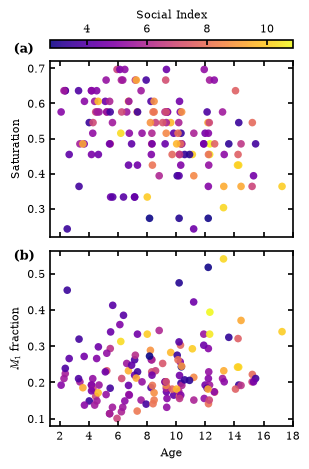

--- Median Values [IQR: 25th, 75th percentiles] ---
Saturation  = 0.52 [0.45, 0.58]
M1 fraction = 0.21 [0.18, 0.27]


In [10]:
"""
Plots figure 4 in the article, with both subfigures and shows confidence intervals for each of the studied
metric.
"""


import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from utilities import set_article_style

set_article_style()

# sharex=True ensures the Age axis is only labeled at the bottom
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3.375, 5), sharex=True)

plt.subplots_adjust(hspace=0.08)
# Define shared scaling for sizes
#point_sizes = (metrics["social_z"] - metrics["social_z"].min() + 0.1) * 80

# --- Top Plot ---
sc = ax1.scatter(
    metrics["age"],
    metrics["cluster_saturation"],
    s=30,
    c=metrics["social_index"],
    cmap="plasma",
    alpha=0.9,
    edgecolors="none" # Cleaner for PDF exports
)
ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax1.set_ylabel("Saturation")

ax1.text(-0.15, 1.05, "(a)", transform=ax1.transAxes, fontweight="bold", fontsize=9)

# --- Bottom Plot ---
ax2.scatter(
    metrics["age"],
    metrics["frac_max"],
    s=30,
    c=metrics["social_index"],
    cmap="plasma",
    alpha=0.9,
    edgecolors="none"
)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax2.set_ylabel(r"$M_1$ fraction")
ax2.set_xlabel("Age")
ax2.text(-0.15, 0.95, "(b)", transform=ax2.transAxes, fontweight="bold", fontsize=9)

# --- Unified Top Colorbar ---
# 'location' places it at the top, 'ax' ensures it spans both subplots
cbar = fig.colorbar(
    sc, 
    ax=[ax1, ax2], 
    location='top', 
    orientation='horizontal', 
    aspect=30,    # Adjusts the thickness/length ratio
    pad=0.03      # Space between the bar and the top plot
)
cbar.set_label("Social Index")


plt.savefig("../Plots/Article/age_social_unified.pdf", bbox_inches="tight")
plt.show()


# 3. Print out the results formatted nicely
sat_series = metrics["cluster_saturation"]
m1_series = metrics["frac_max"]

print("--- Median Values [IQR: 25th, 75th percentiles] ---")
print(
    f"Saturation  = {sat_series.median():.2f} "
    f"[{sat_series.quantile(0.25):.2f}, {sat_series.quantile(0.75):.2f}]"
)
print(
    f"M1 fraction = {m1_series.median():.2f} "
    f"[{m1_series.quantile(0.25):.2f}, {m1_series.quantile(0.75):.2f}]"
)


In [11]:
"""
We test different linear models bbased on the previous plots and results.
"""

from scipy.stats import pearsonr


r, p_value = pearsonr(metrics["age"], metrics["cluster_ratio"])

print("Pearson correlation coefficient (r) age:", r)
print("p-value:", p_value)

r, p_value = pearsonr(metrics["social_index"], metrics["cluster_ratio"])

print("Pearson correlation coefficient (r) social_index:", r)
print("p-value:", p_value)

import statsmodels.formula.api as smf

# Create interaction automatically using formula syntax
model = smf.ols("cluster_ratio ~ age*social_index", data=metrics).fit()

print(model.summary())

model_main = smf.ols("cluster_ratio ~ age + social_index", data=metrics).fit()
model_full = smf.ols("cluster_ratio ~ age * social_index", data=metrics).fit()

f_test = model_full.compare_f_test(model_main)
print("F-test for interaction:", f_test)

Pearson correlation coefficient (r) age: -0.22295356217013
p-value: 0.007230842083173221
Pearson correlation coefficient (r) social_index: 0.22594529101187658
p-value: 0.006468831409350441
                            OLS Regression Results                            
Dep. Variable:          cluster_ratio   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.176
Method:                 Least Squares   F-statistic:                     11.15
Date:                Thu, 03 Sep 2026   Prob (F-statistic):           1.32e-06
Time:                        17:31:29   Log-Likelihood:                 305.59
No. Observations:                 144   AIC:                            -603.2
Df Residuals:                     140   BIC:                            -591.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     

In [12]:
r, p_value = pearsonr(metrics["age"], metrics["cluster_saturation"])

print("Pearson correlation coefficient (r) age:", r)
print("p-value:", p_value)

r, p_value = pearsonr(metrics["social_index"], metrics["cluster_saturation"])

print("Pearson correlation coefficient (r) social_index:", r)
print("p-value:", p_value)

import statsmodels.formula.api as smf

# Create interaction automatically using formula syntax
model = smf.ols("cluster_saturation ~ age*social_index", data=metrics).fit()

print(model.summary())

model_main = smf.ols("cluster_saturation ~ age + social_index", data=metrics).fit()
model_full = smf.ols("cluster_saturation ~ age * social_index", data=metrics).fit()

f_test = model_full.compare_f_test(model_main)
print("F-test for interaction:", f_test)

Pearson correlation coefficient (r) age: -0.28126210165865834
p-value: 0.0006379715881989519
Pearson correlation coefficient (r) social_index: 0.028692460298676656
p-value: 0.7328182641857598
                            OLS Regression Results                            
Dep. Variable:     cluster_saturation   R-squared:                       0.136
Model:                            OLS   Adj. R-squared:                  0.118
Method:                 Least Squares   F-statistic:                     7.369
Date:                Thu, 03 Sep 2026   Prob (F-statistic):           0.000128
Time:                        17:32:13   Log-Likelihood:                 130.82
No. Observations:                 144   AIC:                            -253.6
Df Residuals:                     140   BIC:                            -241.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  

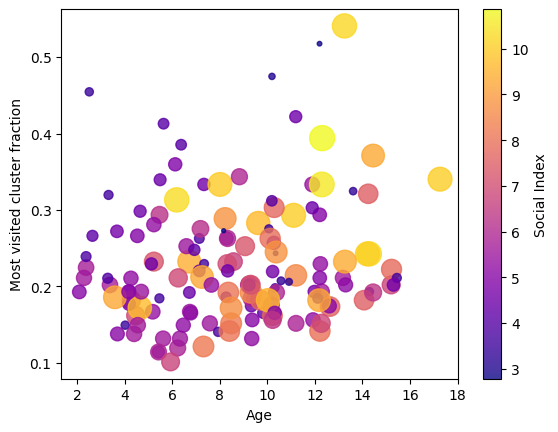

Pearson correlation coefficient (r): 0.14254262704616488
p-value: 0.08832171927626181
Pearson correlation coefficient (r): -0.06239700796004863
p-value: 0.45750427815894434
                            OLS Regression Results                            
Dep. Variable:               frac_max   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.058
Method:                 Least Squares   F-statistic:                     3.945
Date:                Tue, 24 Feb 2026   Prob (F-statistic):            0.00975
Time:                        18:12:41   Log-Likelihood:                 165.08
No. Observations:                 144   AIC:                            -322.2
Df Residuals:                     140   BIC:                            -310.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err 

In [35]:
"""
Other analysis done on the logarithm which are not considered in the article.
"""

metrics["log_social"] = np.log(metrics["social_index"])

r, p_value = pearsonr(metrics["age"], metrics["frac_max"])

print("Pearson correlation coefficient (r):", r)
print("p-value:", p_value)

r, p_value = pearsonr(metrics["log_social"], metrics["frac_max"])

print("Pearson correlation coefficient (r):", r)
print("p-value:", p_value)

# Create interaction automatically using formula syntax
model = smf.ols("frac_max ~ age*log_social", data=metrics).fit()

print(model.summary())

model_main = smf.ols("frac_max ~ age + log_social", data=metrics).fit()
model_full = smf.ols("frac_max ~ age * log_social", data=metrics).fit()

f_test = model_full.compare_f_test(model_main)
print("F-test for interaction:", f_test)

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: cluster_ratio
No. Observations: 144     Method:             ML           
No. Groups:       111     Scale:              0.0005       
Min. group size:  1       Log-Likelihood:     309.3855     
Max. group size:  3       Converged:          Yes          
Mean group size:  1.3                                      
-----------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept         0.162    0.003 60.473 0.000  0.157  0.167
age_z            -0.009    0.003 -3.380 0.001 -0.014 -0.004
social_z          0.012    0.003  4.703 0.000  0.007  0.017
age_z:social_z   -0.008    0.002 -3.132 0.002 -0.012 -0.003
Group Var         0.000    0.008                           

-606.7710270254131


/Users/jan/Desktop/Biologia/Article/venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


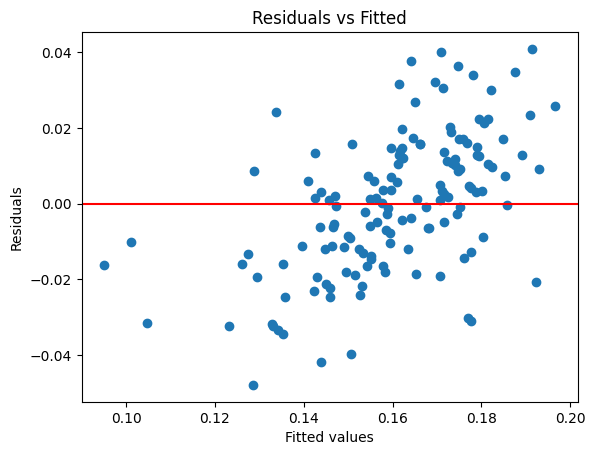

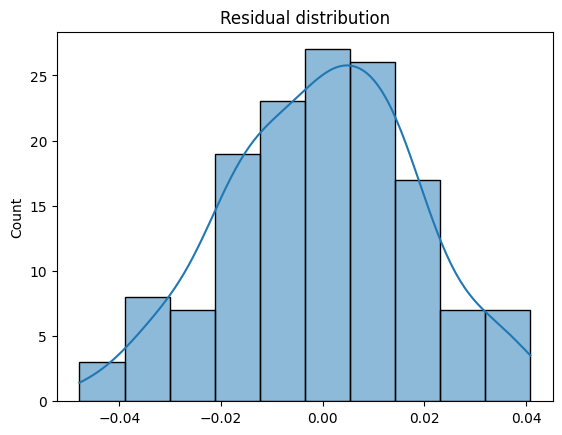

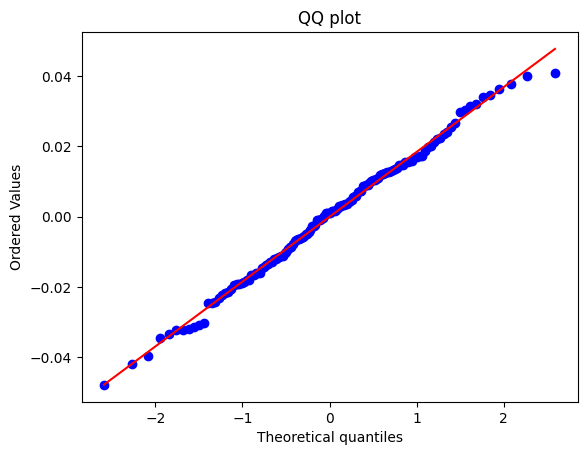

In [33]:
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Fit linear mixed model with normalised age and sociality and using the id as a random variable, since some cows
# the same assigned id.
"""
model = smf.mixedlm(
    "cluster_ratio ~ age_z + social_z",
    data=metrics,
    groups=metrics["real_id"]   # random intercept per cow
)

result = model.fit(reml=False)
print(result.summary())
print(result.aic)
"""
model_int = smf.mixedlm(
    "cluster_ratio ~ age_z * social_z",
    data=metrics,
    groups=metrics["real_id"]   # random intercept per cow
)

result_int = model_int.fit(reml=False)
print(result_int.summary())
print(result_int.aic)


# Get residuals
residuals = result.resid
fitted = result.fittedvalues

# Residual vs Fitted plot
plt.scatter(fitted, residuals)
plt.axhline(0, color='red')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

# Histogram
sns.histplot(residuals, kde=True)
plt.title("Residual distribution")
plt.show()

# QQ-plot
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ plot")
plt.show()



          Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: frac_logit
No. Observations:   144     Method:             ML        
No. Groups:         111     Scale:              0.1090    
Min. group size:    1       Log-Likelihood:     -73.8965  
Max. group size:    3       Converged:          Yes       
Mean group size:    1.3                                   
----------------------------------------------------------
               Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept      -1.299    0.038 -34.012 0.000 -1.374 -1.224
age_z           0.053    0.037   1.416 0.157 -0.020  0.126
social_z       -0.024    0.037  -0.644 0.520 -0.096  0.048
age_z:social_z  0.103    0.034   2.989 0.003  0.035  0.171
Group Var       0.060    0.095                            

159.79292632537363


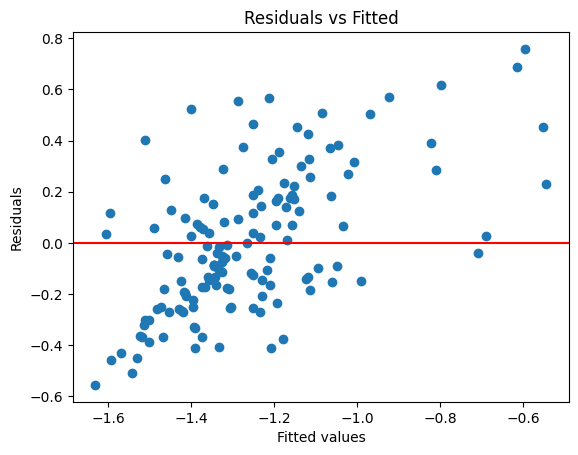

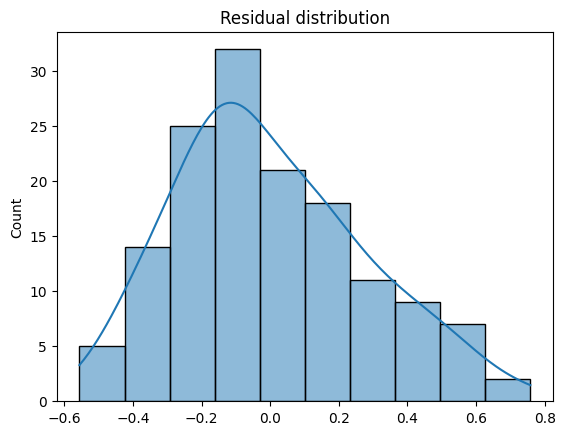

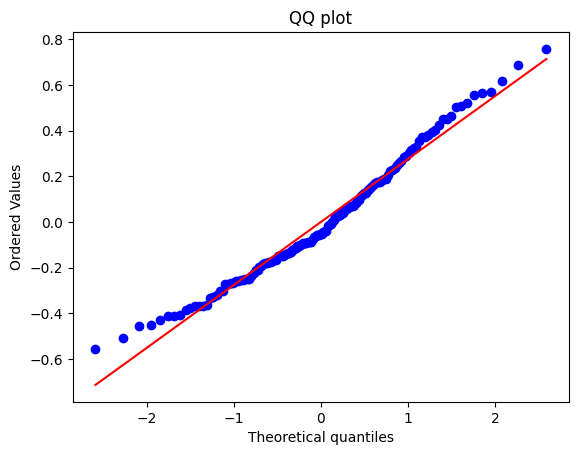

In [46]:
# Fit linear mixed model

epsilon = 1e-6
metrics["frac_adj"] = np.clip(metrics["frac_max"], epsilon, 1 - epsilon)

metrics["frac_logit"] = np.log(
    metrics["frac_adj"] / (1 - metrics["frac_adj"])
)


model = smf.mixedlm(
    "frac_logit ~ age_z * social_z",
    data=metrics,
    groups=metrics["real_id"]   # random intercept per cow
)

result = model.fit(reml=False)
print(result.summary())
print(result.aic)

"""
model_simple = smf.ols("frac_logit ~ age_z*social_z", data=metrics).fit()

print(model_simple.summary())
"""

# Get residuals
residuals = result.resid
fitted = result.fittedvalues

# Residual vs Fitted plot
plt.scatter(fitted, residuals)
plt.axhline(0, color='red')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

# Histogram
sns.histplot(residuals, kde=True)
plt.title("Residual distribution")
plt.show()

# QQ-plot
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ plot")
plt.show()



In [13]:
"""
Other analysis not included, which considers individual trajectories over time.
"""


df_counts = pd.read_csv("../Data/id_clusters.csv")

In [14]:
ts_df = df_counts.merge(
    metrics[["id", "age_z", "social_z"]],
    on="id",
    how="left"
)

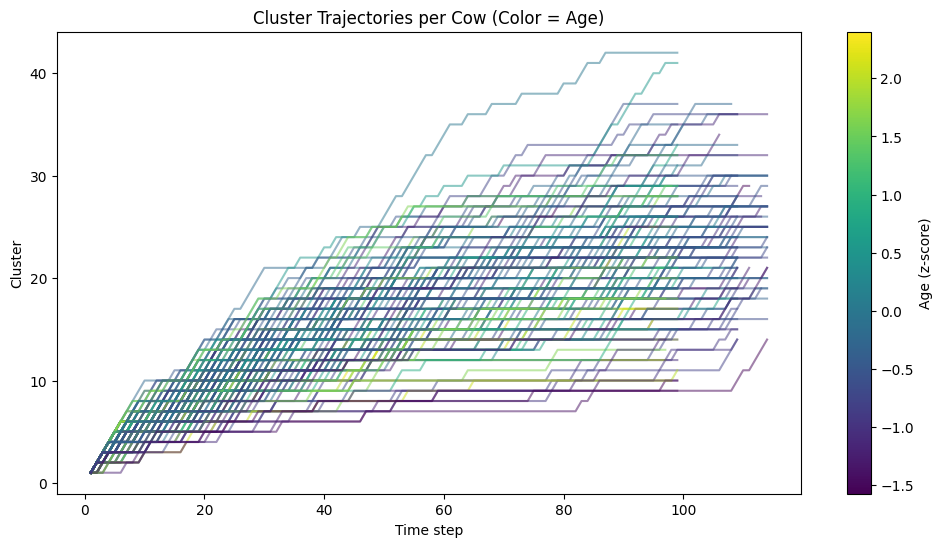

In [52]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Create figure and axes
fig, ax = plt.subplots(figsize=(12,6))

# Normalize age_z for colormap
norm = mcolors.Normalize(vmin=ts_df["social_z"].min(), vmax=ts_df["social_z"].max())
cmap = cm.viridis

# Plot one line per cow
for cow_id, group in ts_df.sort_values("time_step").groupby("id"):
    age_value = group["social_z"].iloc[0]   # same for whole cow
    color = cmap(norm(age_value))
    
    ax.plot(
        group["time_step"],
        group["clusters"],
        color=color,
        alpha=0.5
    )

# Create ScalarMappable and attach colorbar to axes
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # needed even if empty

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Age (z-score)")

ax.set_xlabel("Time step")
ax.set_ylabel("Cluster")
ax.set_title("Cluster Trajectories per Cow (Color = Age)")

plt.show()